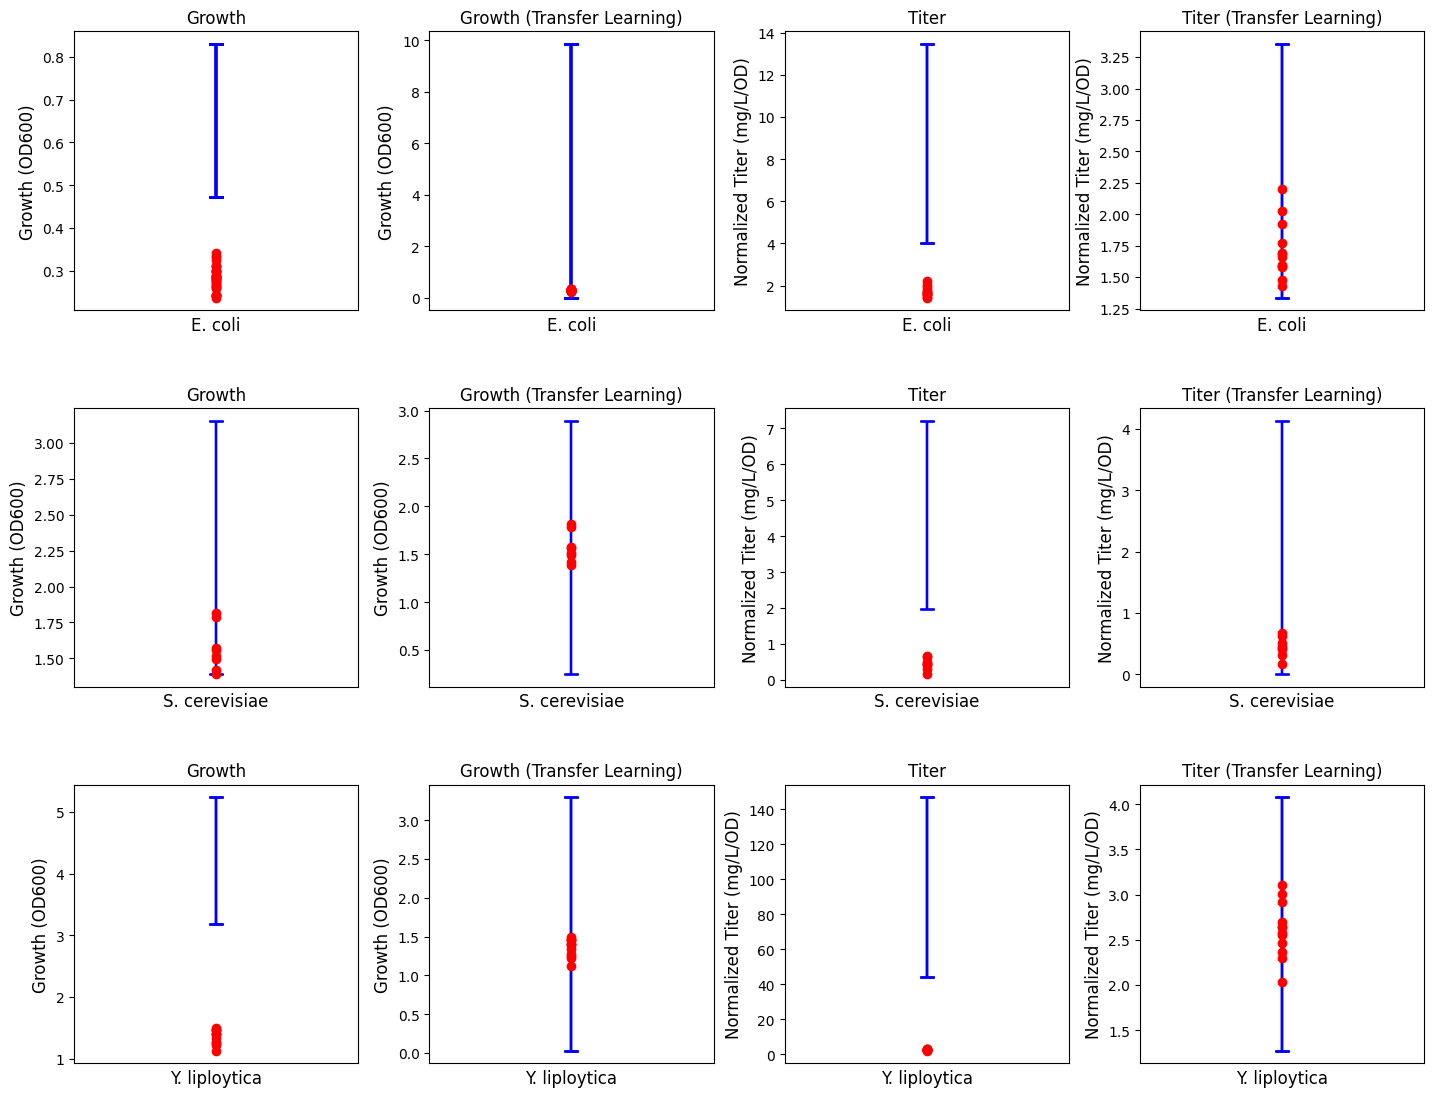

In [ ]:
import pickle
import matplotlib.pyplot as plt

font_size = 12

names = {
    'Ecoli': 'E. coli',
    'Scere': 'S. cerevisiae',
    'Ylipo': 'Y. liploytica',
}

outputs = {
    'Growth': {
        'file_name': 'growth.pkl',
        'y_label': 'Growth (OD600)',
    },
    'Growth (Transfer Learning)': {
        'file_name': 'growth_transfer_learning.pkl',
        'y_label': 'Growth (OD600)',
    },
    'Titer': {
        'file_name': 'titer.pkl',
        'y_label': 'Normalized Titer (mg/L/OD)',
    },
    'Titer (Transfer Learning)': {
        'file_name': 'titer_transfer_learning.pkl',
        'y_label': 'Normalized Titer (mg/L/OD)',
    }
}

for key, info in outputs.items():
    with open(info['file_name'], 'rb') as file:
        outputs[key]['file_name'] = pickle.load(file) 

fig, axes = plt.subplots(3, 4, figsize=(15, 12))
fig.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.94,
    bottom=0.08,
    wspace=0.25,
    hspace=0.35
)

for i, name_dict in enumerate(names.items()):
    name_key, name_value = name_dict
    for j, output in enumerate(outputs):
        axes[i, j].set_title(output, fontsize = font_size)
        axes[i, j].set_xlabel(name_value, fontsize = font_size)
        axes[i, j].set_ylabel(outputs[output]['y_label'], fontsize = font_size)
        axes[i, j].tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
        saved = outputs[output]['file_name'][name_key]
        x_axis = [0] * len(saved['data'])
        axes[i, j].errorbar(
            x_axis,
            saved['mean'],
            [saved['lower'], saved['upper']],
            color = 'blue',
            label = "95% Confidence Interval",
            fmt = 'none',
            capsize = 5,
            zorder = 0,
        )
        axes[i, j].scatter(x_axis, saved['data'], label = "Flight data", color = 'red', zorder = 2)
plt.show()